In [1]:
import torch


# GPU 정보 확인
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"총 메모리: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"할당된 메모리: {torch.cuda.memory_allocated() / 1e6:.1f} MB")
print(f"캐시된 메모리: {torch.cuda.memory_reserved() / 1e6:.1f} MB")


# 메모리 해제
torch.cuda.empty_cache()

GPU: NVIDIA GeForce RTX 4070
총 메모리: 12.4 GB
할당된 메모리: 0.0 MB
캐시된 메모리: 0.0 MB


In [2]:
import torch

print(torch.cuda.is_available())

def print_tensor_state(x):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    x = x.to(device)
    print(x.shape) # 크기
    print(x.dtype) # 데이터 타입 (float32, int64 등)
    print(x.device) # cpu 또는 cuda:0

x = torch.zeros(3, 4)
print_tensor_state(x)
x = torch.ones(3, 4)
print_tensor_state(x)
x = torch.randn(3, 4)
print_tensor_state(x)
x = torch.tensor([1, 2, 3])
print_tensor_state(x)
x = torch.arange(0, 10, 2)
print_tensor_state(x)




True
torch.Size([3, 4])
torch.float32
cuda:0
torch.Size([3, 4])
torch.float32
cuda:0
torch.Size([3, 4])
torch.float32
cuda:0
torch.Size([3])
torch.int64
cuda:0
torch.Size([5])
torch.int64
cuda:0


In [3]:
a = torch.randn(3, 4)
print(f"a: {a}")
b = torch.randn(3, 4)
print(f"b: {b}")

c = a + b
print(f"c = a + b -> {c}")
c = a * b
print(f"c = a * b -> {c}")
c = a @ b.T
print(f"c = a @ b.T -> {c}")
c = torch.matmul(a, b.T)
print(f"c = torch.matmul(a, b.T) -> {c}")



a: tensor([[-0.0203,  0.2118, -0.7429,  0.6329],
        [ 0.3632, -1.1809, -1.5492,  1.1071],
        [ 0.8879, -0.6123,  1.6691, -1.8197]])
b: tensor([[ 0.0986,  2.1357, -0.5169,  0.8739],
        [ 0.7542,  0.3019, -0.0703,  0.8492],
        [-2.5181,  0.4289,  1.4110,  0.0373]])
c = a + b -> tensor([[ 0.0784,  2.3475, -1.2597,  1.5068],
        [ 1.1174, -0.8790, -1.6195,  1.9563],
        [-1.6303, -0.1834,  3.0800, -1.7824]])
c = a * b -> tensor([[-1.9974e-03,  4.5237e-01,  3.8396e-01,  5.5310e-01],
        [ 2.7394e-01, -3.5645e-01,  1.0892e-01,  9.4012e-01],
        [-2.2358e+00, -2.6262e-01,  2.3550e+00, -6.7826e-02]])
c = a @ b.T -> tensor([[ 1.3874,  0.6384, -0.8827],
        [-0.7180,  0.9665, -3.5658],
        [-3.6729, -1.1777, -0.2112]])
c = torch.matmul(a, b.T) -> tensor([[ 1.3874,  0.6384, -0.8827],
        [-0.7180,  0.9665, -3.5658],
        [-3.6729, -1.1777, -0.2112]])


In [4]:
x = torch.randn(2, 3, 4)
print(f"x = {x.shape}")
print(f"x.view(2, 12) -> {x.view(2, 12).shape}")        # [2,3,4] -> [2,12] (메모리 연속 필요)
print(f"x.reshape(2, 12) -> {x.reshape(2, 12).shape}")  # [2,3,4] -> [2,12] (메모리 복사 가능)
print(f"x.permute(2, 0, 1) -> {x.permute(2, 0, 1).shape}")  # [2,3,4] -> [4,2,3]

y = torch.randn(3, 4)
print(f"y.unsqueeze(0) -> {y.unsqueeze(0).shape}")      # [3,4] -> [1,3,4]

z = torch.randn(1, 3, 4)
print(f"z.squeeze(0) -> {z.squeeze(0).shape}")          # [1,3,4] -> [3,4]

x = torch.Size([2, 3, 4])
x.view(2, 12) -> torch.Size([2, 12])
x.reshape(2, 12) -> torch.Size([2, 12])
x.permute(2, 0, 1) -> torch.Size([4, 2, 3])
y.unsqueeze(0) -> torch.Size([1, 3, 4])
z.squeeze(0) -> torch.Size([3, 4])


In [5]:
import numpy as np
img_np = np.random.randint(0, 255, (480, 640, 3), dtype=np.uint8)
img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0

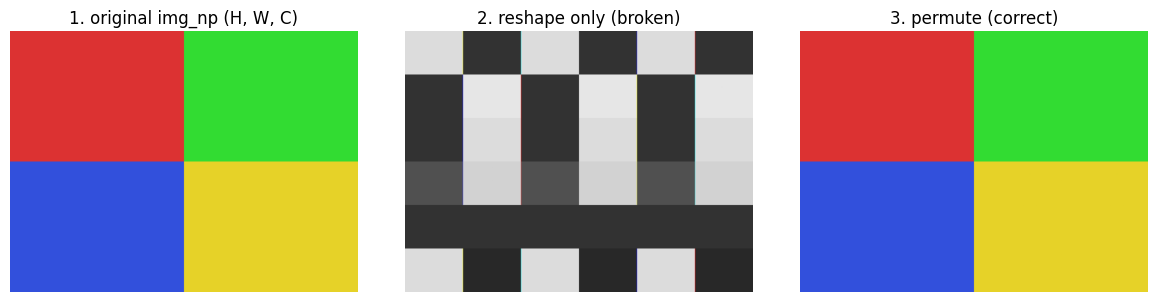

In [6]:
import matplotlib.pyplot as plt

H, W = 480, 640
img_np = np.zeros((H, W, 3), dtype=np.uint8)
img_np[: H // 2, : W // 2] = [220, 50, 50]
img_np[: H // 2, W // 2 :] = [50, 220, 50]
img_np[H // 2 :, : W // 2] = [50, 80, 220]
img_np[H // 2 :, W // 2 :] = [230, 210, 40]

img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0
plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title("1. original img_np (H, W, C)")
plt.axis("off")

wrong = img_tensor.reshape(H, W, 3).cpu().numpy()
plt.subplot(1, 3, 2)
plt.imshow(wrong)
plt.title("2. reshape only (broken)")
plt.axis("off")

img_back = img_tensor.permute(1, 2, 0).cpu().numpy()
plt.subplot(1, 3, 3)
plt.imshow(img_back)
plt.title("3. permute (correct)")
plt.axis("off")

plt.tight_layout()
plt.show()


In [7]:
import torch
x = torch.tensor([2.0, 3.0], requires_grad=True)
w = torch.tensor([1.0, -1.0], requires_grad=True)

y = x * w
loss = y.sum()

loss.backward()

print(x.grad)
print(w.grad)

tensor([ 1., -1.])
tensor([2., 3.])


In [12]:
import os

from PIL import Image
from torch.utils.data import Dataset


class ShapeDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.image_list = sorted(
            f for f in os.listdir(image_dir) if f.endswith(".png")
        )

    def __len__(self):
        return len(self.image_list)
    
    def __getitem__(self, idx):
        filename = self.image_list[idx]
        img_path = os.path.join(self.image_dir, filename)
        image = Image.open(img_path).convert("RGB")
        label = int(filename.split("_")[0])

        if self.transform:
            image = self.transform(image)

        return image, label
    
datasets = ShapeDataset("./demo_dataset/images")
print(f"총 {len(datasets)} 장")

for dataset in datasets:
    image, label = dataset
    print(f"크기: {image.size}, 라벨: {label}")

총 60 장
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 0
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 1
크기: (64, 64), 라벨: 2
크기: (64, 64), 라벨: 2
크기: (64, 64), 라벨: 2
크기: (64, 64), 라벨: 2
크기: (64, 64), 라벨: 2
크기: (64, 64), 라벨: 2
크기: (64, 64), 라벨: 2
크기: (64, 64), 라벨: 2
크기: (64, 64), 라벨: 2
크기: (64, 64),

In [13]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
])

dataset = ShapeDataset("./demo_dataset/images", transform=transform)
dataloader = DataLoader(
    dataset,
    batch_size=8,
    num_workers=0,
    pin_memory=True,
    drop_last=True,
)

device = "cuda" if torch.cuda.is_available() else "cpu"

images, labels = next(iter(dataloader))
print(f"images: {images.shape}, dtype={images.dtype}")
print(f"labels: {labels.shape}, {labels.tolist()}")

for batch_idx, (images, labels) in enumerate(dataloader):
    images = images.to(device)
    labels = images.to(device)

images: torch.Size([8, 3, 64, 64]), dtype=torch.float32
labels: torch.Size([8]), [0, 0, 0, 0, 0, 0, 0, 0]


In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(128, 10)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()


    scheduler.step()
    train_acc = 100. * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}] ")
    print(f"Loss: {running_loss/len(trainloader):.4f} ")
    print(f"Acc: {train_acc:.2f}%")

Epoch [1/50] 
Loss: 1.5259 
Acc: 44.98%
Epoch [2/50] 
Loss: 1.2244 
Acc: 56.34%
Epoch [3/50] 
Loss: 1.1188 
Acc: 60.30%
Epoch [4/50] 
Loss: 1.0503 
Acc: 63.00%
Epoch [5/50] 
Loss: 1.0015 
Acc: 64.45%
Epoch [6/50] 
Loss: 0.9572 
Acc: 66.36%
Epoch [7/50] 
Loss: 0.9254 
Acc: 67.24%
Epoch [8/50] 
Loss: 0.8917 
Acc: 68.73%
Epoch [9/50] 
Loss: 0.8630 
Acc: 69.85%
Epoch [10/50] 
Loss: 0.8338 
Acc: 70.98%
Epoch [11/50] 
Loss: 0.8122 
Acc: 71.80%
Epoch [12/50] 
Loss: 0.7911 
Acc: 72.68%
Epoch [13/50] 
Loss: 0.7716 
Acc: 73.27%
Epoch [14/50] 
Loss: 0.7532 
Acc: 73.92%
Epoch [15/50] 
Loss: 0.7311 
Acc: 74.67%
Epoch [16/50] 
Loss: 0.7249 
Acc: 74.87%
Epoch [17/50] 
Loss: 0.7077 
Acc: 75.64%
Epoch [18/50] 
Loss: 0.6944 
Acc: 76.10%
Epoch [19/50] 
Loss: 0.6797 
Acc: 76.58%
Epoch [20/50] 
Loss: 0.6700 
Acc: 76.77%
Epoch [21/50] 
Loss: 0.6567 
Acc: 77.28%
Epoch [22/50] 
Loss: 0.6471 
Acc: 77.87%
Epoch [23/50] 
Loss: 0.6394 
Acc: 78.04%
Epoch [24/50] 
Loss: 0.6286 
Acc: 78.37%
Epoch [25/50] 
Loss: 0.62

In [21]:
import torchvision.models as models

model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)